# Student Credit Risk Assessment
## Extreme Gradient Boosting (XGBoost) Baseline

This notebook develops the Extreme Gradient Boosting (XGBoost) baseline model for the Student Credit Risk Assessment project. It uses the final post-EDA dataset and serves as the XGBoost implementation for comparative evaluation against the previously developed machine learning models.

## 1. Project Context



This notebook develops the **Extreme Gradient Boosting (XGBoost) model** for the Student Credit Risk Assessment project using the final post-EDA modelling dataset. As the first baseline model in the research pipeline, it establishes an interpretable benchmark against which subsequent machine learning models and the Nemotron reasoning model can be systematically evaluated.





### 1.1 Problem Statement



Financial institutions often encounter **thin-file borrowers**, particularly students with limited credit histories, making conventional credit risk assessment challenging. Inaccurate risk estimation may result in increased default rates, reduced financial inclusion, or overly conservative lending practices.

This notebook addresses the binary classification problem of predicting whether a borrower is likely to default (`default_flag`) using demographic, academic, financial, behavioural, and banking-related features derived during the data generation and exploratory data analysis stages.



### 1.2 Why XGBoost?

Extreme Gradient Boosting (XGBoost) is selected as the final machine learning model to investigate whether gradient-boosted decision trees can further improve predictive performance for student credit risk assessment. Unlike bagging-based ensemble methods such as Random Forest, XGBoost constructs trees sequentially, where each new tree is trained to minimise the prediction errors of the existing ensemble.

The algorithm incorporates gradient boosting, regularisation, shrinkage, and efficient tree optimisation to improve predictive performance while controlling overfitting. These characteristics have made XGBoost one of the most widely adopted algorithms for structured tabular data and financial risk modelling.

By evaluating XGBoost under the same preprocessing pipeline, experimental split strategies, evaluation metrics, explainability framework, and fairness assessment adopted throughout this research, direct comparison with Logistic Regression, Support Vector Machine, Random Forest, and the Nemotron reasoning framework becomes possible.



### 1.3 Research Objectives

The primary objectives of this notebook are to:

- Develop and evaluate a reproducible XGBoost baseline for student credit risk prediction.
- Evaluate model performance under three experimental data-splitting strategies.
- Compare baseline and hyperparameter-tuned model performance.
- Analyse feature importance using Gain-based feature importance and SHAP explanations.
- Assess fairness across selected demographic groups.
- Compare the behaviour of XGBoost with the Nemotron reasoning model.





### 1.4 Expected Outcomes

By the completion of this notebook, the following outcomes are expected:

- A validated XGBoost baseline model.
- Performance evaluation across three experimental strategies.
- Comparative analysis between baseline and tuned XGBoost configurations.
- Identification of influential predictive features through gain-based importance and SHAP analysis.
- A comprehensive assessment of XGBoost within the proposed Student Credit Risk Assessment framework.



## 2. Dataset Foundation

This section loads and verifies the final modelling dataset before feature selection and preprocessing. The objective is to confirm that the dataset has been imported correctly, follows the expected schema, and is ready for subsequent modelling stages.

### 2.1 Import Libraries

In [1]:
# ==========================================================
# 2.1 Import Libraries
# ==========================================================

import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)

plt.style.use("default")
sns.set_theme(style="whitegrid")

### 2.2 Load Dataset

In [2]:
# ==========================================================
# 2.2 Load Dataset
# ==========================================================

DATA_PATH = "../data/master_v6_post_eda.csv"

TARGET_COLUMN = "default_flag"

IDENTIFIER_COLUMNS = [
    "student_id"
]

LEAKAGE_COLUMNS = [
    "default_probability"
]

RANDOM_STATE = 42

student_df = pd.read_csv(DATA_PATH)

print(f"Dataset Shape : {student_df.shape}")

display(student_df.head())

Dataset Shape : (21000, 38)


,student_id,synthetic_age,enrollment_type,academic_year,major_category,gpa_direction,credit_hours_current,semesters_enrolled,expected_total_semesters,remaining_semesters,monthly_inflow_mean,cash_flow_cv,aid_disbursement_flag,aid_amount,estimated_tuition,estimated_living_cost,synthetic_debt_load,campus_employment,gig_income_flag,bill_payment_rate,savings_behavior,subscription_count,prior_delinquency,application_week,semester_phase,academic_calendar_flag,ecs,gdi,acr,cfri,opr,tgb,spra,sei,default_probability,default_flag,credit_bin,synthetic_anomaly_flag
0,STU_002313,21.9141,Full-time,2,Business,Stable,13.3372,4,8,4,993.4006,0.7318,0,0.0000,4636.5845,6660.3798,6640.0101,0,1,0.8795,Sporadic,3,0,9,Early,1,0.5000,0.0000,0.3517,0.2682,0.8795,0.1829,0.3289,0.3259,0.0341,0,12-15 (Full),0
1,STU_016846,22.0878,Full-time,3,Arts,Stable,16.3653,5,8,3,2834.8034,0.1298,1,4725.6159,8071.4889,3797.3567,12767.0852,0,1,0.6724,Sporadic,0,0,6,Late,1,0.6250,0.0000,1.3535,0.8702,0.6724,0.1466,0.1502,0.8643,0.0046,0,15+ (Overload),0
2,STU_006106,23.4131,Full-time,2,Business,Stable,17.8260,4,8,4,530.2470,0.1648,1,6628.3747,6700.1349,3990.6708,5113.1182,0,0,0.8811,Sporadic,2,0,10,Early,1,0.5000,0.0000,0.8184,0.8352,0.8811,0.1885,0.1016,0.5592,0.0042,0,15+ (Overload),0
3,STU_018083,20.7062,Full-time,2,STEM,Stable,15.0142,3,8,5,959.2160,0.0678,1,3527.0611,8437.0759,5858.2115,5245.2304,0,1,0.9265,No Savings,2,0,5,Mid,1,0.3750,0.0000,0.5151,0.9322,0.9265,0.2092,0.0492,0.3701,0.0062,0,15+ (Overload),0
4,STU_011336,19.7460,Part-time,2,Business,Declining,7.0056,3,10,7,1475.7728,0.2107,0,0.0000,7062.3194,4216.9331,6813.0712,1,0,0.8544,Sporadic,5,0,4,Mid,1,0.3000,-1.0000,0.5234,0.7893,0.8544,0.2356,0.1279,0.1517,0.0881,0,6-11 (Half),0


### 2.3 Dataset Overview

In [3]:
# ==========================================================
# 2.3 Dataset Overview
# ==========================================================

display(student_df.describe().T)

display(student_df.describe(include="object").T)

,count,mean,std,min,25%,50%,75%,max
synthetic_age,21000.0000,21.5256,1.7602,18.0000,20.2972,21.5093,22.7265,29.5624
academic_year,21000.0000,2.4066,1.0111,1.0000,2.0000,2.0000,3.0000,4.0000
credit_hours_current,21000.0000,13.4476,2.7659,3.0000,12.0000,13.7395,15.3322,19.0000
semesters_enrolled,21000.0000,4.2355,1.9720,1.0000,3.0000,4.0000,6.0000,8.0000
expected_total_semesters,21000.0000,8.4166,1.0692,8.0000,8.0000,8.0000,8.0000,12.0000
remaining_semesters,21000.0000,4.1811,2.2257,1.0000,2.0000,4.0000,6.0000,11.0000
monthly_inflow_mean,21000.0000,1314.3130,544.8404,265.6408,925.7381,1210.8788,1591.7095,7516.4249
cash_flow_cv,21000.0000,0.2849,0.1595,0.0026,0.1611,0.2642,0.3870,0.9055
aid_disbursement_flag,21000.0000,0.6489,0.4773,0.0000,0.0000,1.0000,1.0000,1.0000
aid_amount,21000.0000,3080.9336,2599.2379,0.0000,0.0000,3268.6793,5363.0736,7499.9704


,count,unique,top,freq
student_id,21000,21000,STU_002313,1
enrollment_type,21000,2,Full-time,17895
major_category,21000,4,STEM,8340
gpa_direction,21000,3,Stable,9453
savings_behavior,21000,3,Sporadic,9413
semester_phase,21000,3,Mid,10598
credit_bin,21000,4,12-15 (Full),11619


### 2.4 Dataset Structure

In [4]:
# ==========================================================
# 2.4 Dataset Structure
# ==========================================================

student_df.info()

duplicate_rows = student_df.duplicated().sum()
missing_values = student_df.isna().sum().sum()

print(f"\nDuplicate Rows : {duplicate_rows}")
print(f"Missing Values : {missing_values}")


print(f"Target Column : '{TARGET_COLUMN}'")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21000 entries, 0 to 20999
Data columns (total 38 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   student_id                21000 non-null  object 
 1   synthetic_age             21000 non-null  float64
 2   enrollment_type           21000 non-null  object 
 3   academic_year             21000 non-null  int64  
 4   major_category            21000 non-null  object 
 5   gpa_direction             21000 non-null  object 
 6   credit_hours_current      21000 non-null  float64
 7   semesters_enrolled        21000 non-null  int64  
 8   expected_total_semesters  21000 non-null  int64  
 9   remaining_semesters       21000 non-null  int64  
 10  monthly_inflow_mean       21000 non-null  float64
 11  cash_flow_cv              21000 non-null  float64
 12  aid_disbursement_flag     21000 non-null  int64  
 13  aid_amount                21000 non-null  float64
 14  estima

### 2.5 Target Variable Analysis

In [5]:
target_summary = (
    student_df[TARGET_COLUMN]
    .value_counts()
    .rename_axis(TARGET_COLUMN)
    .reset_index(name="Count")
)

target_summary["Percentage"] = (
    target_summary["Count"] /
    len(student_df) * 100
).round(2)

display(target_summary)


,default_flag,Count,Percentage
0,0,20318,96.7500
1,1,682,3.2500


### 2.6 Dataset Summary

In [6]:
# ==========================================================
# 2.6 Dataset Summary
# ==========================================================

summary = pd.DataFrame(
    {
        "Metric": [
            "Rows",
            "Columns",
            "Duplicate Rows",
            "Missing Values",
        ],
        "Value": [
            student_df.shape[0],
            student_df.shape[1],
            duplicate_rows,
            missing_values,
        ],
    }
)

display(summary)

,Metric,Value
0,Rows,21000
1,Columns,38
2,Duplicate Rows,0
3,Missing Values,0


### 2.7 Findings 
The modelling dataset was successfully loaded and verified. Structural validation confirmed the expected schema, the target variable was identified successfully, and no duplicate records or missing values were detected. The dataset is ready for feature validation and selection.

## 3. Feature Validation & Selection

### 3.1 Feature Selection Objective

Establish a common modelling feature set for all machine learning models by removing leakage variables, identifier columns, synthetic diagnostic attributes, and redundant features identified during the EDA.

### 3.2 Remove Leakage Features

In [7]:
# ==========================================================
# 3.2 Remove Leakage Features
# ==========================================================

processed_df = student_df.drop(columns=LEAKAGE_COLUMNS).copy()

print(f"Removed Leakage Columns : {LEAKAGE_COLUMNS}")

print(f"Dataset Shape : {processed_df.shape}")

Removed Leakage Columns : ['default_probability']
Dataset Shape : (21000, 37)


### 3.3 Remove Identifier Features

In [8]:
# ==========================================================
# 3.3 Remove Identifier Features
# ==========================================================

processed_df.drop(columns=IDENTIFIER_COLUMNS, inplace=True)

print(f"Removed Identifier Columns : {IDENTIFIER_COLUMNS}")

print(f"Dataset Shape : {processed_df.shape}")

Removed Identifier Columns : ['student_id']
Dataset Shape : (21000, 36)


### 3.4 Feature Validation


Feature selection decisions are guided by three principles:

- Leakage and identifier variables are removed.
- Redundant representations identified during exploratory data analysis are eliminated.
- Engineered features are retained where they provide a more suitable representation of the underlying concept for modelling.

The final feature set is established once and reused across every machine learning model to ensure a fair comparison.

In [9]:
# ==========================================================
# 3.4 Feature Validation
# ==========================================================

feature_decisions = pd.DataFrame(
    {
        "Feature": [
            "student_id",
            "default_probability",
            "synthetic_anomaly_flag",
            "expected_total_semesters",
            "remaining_semesters",
            "gpa_direction",
            "bill_payment_rate",
            "cash_flow_cv",
            "credit_bin"
        ],
        "Decision": [
            "Remove",
            "Remove",
            "Remove",
            "Remove",
            "Remove",
            "Remove",
            "Remove",
            "Remove",
            "Remove"
        ],
        "Reason": [
            "Identifier",
            "Target Leakage",
            "Synthetic Diagnostic",
            "Redundant Temporal Feature",
            "Redundant Temporal Feature",
            "Represented by GDI",
            "Represented by OPR",
            "Represented by CFRI",
            "Is an interpreter of credit_hours_current"
        ]
    }
)

display(feature_decisions)

,Feature,Decision,Reason
0,student_id,Remove,Identifier
1,default_probability,Remove,Target Leakage
2,synthetic_anomaly_flag,Remove,Synthetic Diagnostic
3,expected_total_semesters,Remove,Redundant Temporal Feature
4,remaining_semesters,Remove,Redundant Temporal Feature
5,gpa_direction,Remove,Represented by GDI
6,bill_payment_rate,Remove,Represented by OPR
7,cash_flow_cv,Remove,Represented by CFRI
8,credit_bin,Remove,Is an interpreter of credit_hours_current


In [10]:
# ==========================================================
# Apply Feature Selection
# ==========================================================

FEATURES_TO_REMOVE = feature_decisions.loc[
    feature_decisions["Decision"] == "Remove",
    "Feature"
].tolist()

processed_df.drop(
    columns=FEATURES_TO_REMOVE,
    inplace=True,
    errors="ignore"
)

print(f"Remaining Features : {processed_df.shape[1]}")

Remaining Features : 29


### 3.5 Selected Feature Set

In [11]:
selected_features = processed_df.drop(
    columns=TARGET_COLUMN
).columns.tolist()

display(
    pd.DataFrame(
        selected_features,
        columns=["Feature"]
    )
)

,Feature
0,synthetic_age
1,enrollment_type
2,academic_year
3,major_category
4,credit_hours_current
5,semesters_enrolled
6,monthly_inflow_mean
7,aid_disbursement_flag
8,aid_amount
9,estimated_tuition


### 3.6 Feature Selection Summary



Feature selection was performed using a combination of deterministic removal, exploratory data analysis and domain knowledge. Leakage variables, identifier columns and redundant feature representations were excluded to obtain a consistent modelling dataset.

The resulting feature set will be reused across every machine learning model to ensure a fair comparison throughout this study.

In [12]:
# ==========================================================
# 3.6 Feature Selection Summary
# ==========================================================

summary = pd.DataFrame(
    {
        "Metric": [
            "Initial Features",
            "Removed Features",
            "Final Features",
            "Target Variable"
        ],
        "Value": [
            student_df.shape[1] - 1,
            len(FEATURES_TO_REMOVE),
            len(selected_features),
            TARGET_COLUMN
        ]
    }
)

display(summary)

,Metric,Value
0,Initial Features,37
1,Removed Features,9
2,Final Features,28
3,Target Variable,default_flag


### 3.7 Findings



- Leakage, identifier and redundant features were removed before model development.
- The final feature set combines original and engineered variables while avoiding duplicate representations.
- A common feature set has been established and will be used across all machine learning models to ensure a consistent experimental comparison.

## 4. Preprocessing

### 4.1 Preprocessing Objective


The objective of this section is to verify that the selected feature set is suitable for XGBoost model development by examining feature types, missing values, and overall data consistency before constructing the modelling datasets.

Although XGBoost is generally insensitive to feature scaling, the common preprocessing pipeline established throughout this research is retained to ensure methodological consistency across all evaluated machine learning models and enable fair comparative analysis.

### 4.2 Feature Classification

In [13]:
# ==========================================================
# 4.2 Feature Classification
# ==========================================================

categorical_features = [
    column
    for column in processed_df.select_dtypes(include="object").columns
    if column != TARGET_COLUMN
]

numerical_features = [
    column
    for column in processed_df.select_dtypes(include=["int64", "float64"]).columns
    if column != TARGET_COLUMN
]

print(f"Numerical Features   : {len(numerical_features)}")
print(f"Categorical Features : {len(categorical_features)}")

print("\nNumerical Features")
print("------------------")
print(numerical_features)

print("\nCategorical Features")
print("--------------------")
print(categorical_features)

Numerical Features   : 24
Categorical Features : 4

Numerical Features
------------------
['synthetic_age', 'academic_year', 'credit_hours_current', 'semesters_enrolled', 'monthly_inflow_mean', 'aid_disbursement_flag', 'aid_amount', 'estimated_tuition', 'estimated_living_cost', 'synthetic_debt_load', 'campus_employment', 'gig_income_flag', 'subscription_count', 'prior_delinquency', 'application_week', 'academic_calendar_flag', 'ecs', 'gdi', 'acr', 'cfri', 'opr', 'tgb', 'spra', 'sei']

Categorical Features
--------------------
['enrollment_type', 'major_category', 'savings_behavior', 'semester_phase']


### 4.3 Missing Value Verification

In [14]:
# ==========================================================
# 4.3 Missing Value Verification
# ==========================================================

missing_values = processed_df.isna().sum()

missing_summary = (
    missing_values[missing_values > 0]
    .sort_values(ascending=False)
)

if missing_summary.empty:
    print("No missing values found.")
else:
    display(missing_summary)

No missing values found.


### 4.4 Data Type Verification

In [15]:
# ==========================================================
# 4.4 Data Type Verification
# ==========================================================

dtype_summary = pd.DataFrame(
    {
        "Feature": processed_df.columns,
        "Data Type": processed_df.dtypes.astype(str).values
    }
)

display(dtype_summary)

,Feature,Data Type
0,synthetic_age,float64
1,enrollment_type,object
2,academic_year,int64
3,major_category,object
4,credit_hours_current,float64
5,semesters_enrolled,int64
6,monthly_inflow_mean,float64
7,aid_disbursement_flag,int64
8,aid_amount,float64
9,estimated_tuition,float64


### 4.5 Preprocessing Summary

The selected feature set was successfully verified prior to model development. Numerical and categorical variables were identified, missing values were inspected, and feature data types were validated to ensure compatibility with the preprocessing workflow.

Although XGBoost does not require feature scaling for predictive performance, the common preprocessing pipeline established throughout this research was retained. Maintaining identical preprocessing across all evaluated machine learning models ensures that observed performance differences arise from the learning algorithms themselves rather than variations in data preparation.

In [16]:
# ==========================================================
# 4.5 Preprocessing Summary
# ==========================================================

summary = pd.DataFrame(
    {
        "Metric": [
            "Total Features",
            "Numerical Features",
            "Categorical Features",
            "Missing Values"
        ],
        "Value": [
            processed_df.shape[1] - 1,
            len(numerical_features),
            len(categorical_features),
            processed_df.isna().sum().sum()
        ]
    }
)

display(summary)

,Metric,Value
0,Total Features,28
1,Numerical Features,24
2,Categorical Features,4
3,Missing Values,0


### 4.6 Findings

- Numerical and categorical variables were successfully identified for preprocessing.
- No missing values were detected within the selected modelling dataset.
- Feature data types were verified and confirmed to be suitable for subsequent encoding and model preparation.
- A consistent preprocessing pipeline was maintained across all machine learning models to support fair experimental comparison.

## 5. Model Preparation

### 5.1 Model Preparation Objective


The objective of this section is to prepare the processed feature set for XGBoost model development. This includes constructing the feature matrix and target variable, generating the experimental train-test splits, transforming the input features using the common preprocessing pipeline, and producing the final modelling datasets required for training.

Although XGBoost does not require feature scaling for predictive performance, the same preprocessing workflow is retained to ensure methodological consistency across all evaluated machine learning models and enable direct comparison under identical experimental conditions.

### 5.2 Feature Matrix (X, y)

In [17]:
# ==========================================================
# 5.2 Feature Matrix (X, y)
# ==========================================================

X = processed_df.drop(columns=TARGET_COLUMN)

y = processed_df[TARGET_COLUMN]

print(f"Feature Matrix Shape : {X.shape}")
print(f"Target Shape         : {y.shape}")

Feature Matrix Shape : (21000, 28)
Target Shape         : (21000,)


### 5.3 Train-Test Split

In [18]:
# ==========================================================
# 5.3 Train-Test Split
# ==========================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print(f"Training Samples : {X_train.shape[0]}")
print(f"Testing Samples  : {X_test.shape[0]}")

Training Samples : 16800
Testing Samples  : 4200


### 5.4 Feature Transformation


In [19]:
# ==========================================================
# 5.4 Feature Transformation
# ==========================================================

from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

scaler = StandardScaler()

X_train_cat = encoder.fit_transform(
    X_train[categorical_features]
)

X_test_cat = encoder.transform(
    X_test[categorical_features]
)

X_train_num = scaler.fit_transform(
    X_train[numerical_features]
)

X_test_num = scaler.transform(
    X_test[numerical_features]
)

### 5.5 Model Input Preparation



The preprocessing pipeline is fitted using the training data and subsequently applied to both the training and testing partitions. This approach prevents information leakage while ensuring that XGBoost training and evaluation are performed on consistently transformed feature representations.

In [20]:
# ==========================================================
# 5.5 Model Input Preparation
# ==========================================================


X_train_final = np.hstack(
    [X_train_num, X_train_cat]
)

X_test_final = np.hstack(
    [X_test_num, X_test_cat]
)

print(f"Training Matrix : {X_train_final.shape}")
print(f"Testing Matrix  : {X_test_final.shape}")

Training Matrix : (16800, 36)
Testing Matrix  : (4200, 36)


### 5.6 Preparation Summary

The processed dataset was successfully converted into model-ready training and testing datasets for all three experimental configurations. A consistent preprocessing workflow consisting of categorical feature encoding and numerical feature standardisation was applied prior to constructing the final feature matrices.

Although XGBoost does not require feature scaling for predictive performance, retaining the common preprocessing pipeline ensures methodological consistency across Logistic Regression, Support Vector Machine, Random Forest, and XGBoost, thereby enabling direct comparison of model behaviour under identical experimental conditions.

In [21]:
# ==========================================================
# 5.6 Preparation Summary
# ==========================================================

summary = pd.DataFrame(
    {
        "Metric": [
            "Training Samples",
            "Testing Samples",
            "Numerical Features",
            "Categorical Features",
            "Encoded Features"
        ],
        "Value": [
            X_train.shape[0],
            X_test.shape[0],
            len(numerical_features),
            len(categorical_features),
            X_train_final.shape[1]
        ]
    }
)

display(summary)

,Metric,Value
0,Training Samples,16800
1,Testing Samples,4200
2,Numerical Features,24
3,Categorical Features,4
4,Encoded Features,36


### 5.7 Findings


- Feature matrices and target vectors were successfully prepared for model development.
- Three experimental datasets corresponding to the conventional, semester-aware, and temporal split strategies were generated.
- Feature transformation was completed using the common preprocessing workflow established for this study.
- The resulting modelling datasets are now ready for XGBoost training and evaluation.

## 6. Experimental Design

### 6.1 Experimental Objective


This section defines the experimental framework used to evaluate XGBoost under three complementary data partitioning strategies. Each experiment assesses both baseline and hyperparameter-optimised models using identical evaluation metrics, ensuring direct comparison with the other machine learning models developed throughout this research.

The objective is to evaluate predictive capability, robustness, and generalisation performance while maintaining a consistent and reproducible experimental methodology.

### 6.2 Experiment 1 – Stratified Split

Experiment 1 represents the baseline evaluation strategy. The dataset is partitioned using a stratified train-test split, ensuring that the class distribution of the target variable is preserved in both subsets. This experiment provides the primary benchmark for subsequent comparisons.

### 6.3 Experiment 2 – Semester-aware Stratified Split

Experiment 2 extends the baseline strategy by maintaining both the target class distribution and a balanced academic semester distribution across the training and testing datasets. This experiment evaluates whether maintaining comparable academic progression improves model generalisation.

### 6.4 Experiment 3 – Temporal Split

Experiment 3 evaluates model performance under a chronological training strategy. Earlier academic periods are used for training while later periods are reserved for testing, simulating a realistic deployment scenario where future student outcomes must be predicted using historical observations.

### 6.5 Evaluation Metrics

In [22]:
# ==========================================================
# 6.5 Evaluation Metrics
# ==========================================================

evaluation_metrics = pd.DataFrame(
    {
        "Metric": [
            "Accuracy",
            "Precision",
            "Recall",
            "F1-Score",
            "ROC-AUC",
            "PR-AUC"
        ],
        "Purpose": [
            "Overall classification performance",
            "Positive prediction reliability",
            "Default detection capability",
            "Balance between precision and recall",
            "Overall discrimination ability",
            "Performance under class imbalance"
        ]
    }
)

display(evaluation_metrics)

,Metric,Purpose
0,Accuracy,Overall classification performance
1,Precision,Positive prediction reliability
2,Recall,Default detection capability
3,F1-Score,Balance between precision and recall
4,ROC-AUC,Overall discrimination ability
5,PR-AUC,Performance under class imbalance


### 6.6 Cross-Validation Strategy

Model selection and hyperparameter optimisation will use Stratified K-Fold Cross-Validation to preserve the target class distribution within each fold. Five-fold cross-validation will be adopted as the primary validation strategy.

In [23]:
# ==========================================================
# 6.6 Cross-Validation Strategy
# ==========================================================

from sklearn.model_selection import StratifiedKFold

cv_5 = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)



print("Cross-Validation : 5-Fold Stratified")


Cross-Validation : 5-Fold Stratified


### 6.7 Hyperparameter Optimisation Strategy

Hyperparameter optimisation will be performed using Randomised Search Cross-Validation to identify the optimal XGBoost configuration. The search explores multiple combinations of boosting parameters, including the number of trees, learning rate, tree depth, subsampling strategy, and regularisation parameters, to maximise predictive performance while maintaining generalisation capability.

### 6.8 Experimental Summary

The experimental framework combines three complementary train-test partitioning strategies with comprehensive evaluation metrics and hyperparameter optimisation to assess XGBoost under multiple deployment scenarios.

Maintaining the same experimental design used throughout this research ensures that differences in predictive performance can be attributed to the learning algorithm rather than changes in methodology, enabling fair comparison across all evaluated machine learning models.

In [24]:
# ==========================================================
# 6.8 Experimental Summary
# ==========================================================

summary = pd.DataFrame(
    {
        "Component": [
            "Experiments",
            "Train-Test Strategies",
            "Cross-Validation",
            "Hyperparameter Search",
            "Evaluation Metrics"
        ],
        "Configuration": [
            "3",
            "Stratified, Semester-aware, Temporal",
            "5-Fold Stratified",
            "Grid Search",
            "Accuracy, Precision, Recall, F1, ROC-AUC, PR-AUC"
        ]
    }
)

display(summary)

,Component,Configuration
0,Experiments,3
1,Train-Test Strategies,"Stratified, Semester-aware, Temporal"
2,Cross-Validation,5-Fold Stratified
3,Hyperparameter Search,Grid Search
4,Evaluation Metrics,"Accuracy, Precision, Recall, F1, ROC-AUC, PR-AUC"


### 6.9 Findings

- Three complementary experimental configurations were established to evaluate the XGBoost classifier under conventional, semester-aware, and temporal data partitioning strategies.
- Multiple evaluation metrics, including Accuracy, Precision, Recall, F1-Score, ROC-AUC, and PR-AUC, were selected to provide a comprehensive assessment of predictive performance.
- Five-fold Stratified Cross-Validation and Randomised Hyperparameter Optimisation were incorporated to improve model robustness and reduce the risk of overfitting.
- The experimental framework provides a consistent basis for comparing XGBoost with the remaining machine learning models developed within this research.

## 7. Experiment Execution

### 7.1 Experiment Execution Objective



This section implements the Extreme Gradient Boosting (XGBoost) classifier under the three experimental configurations established earlier. Each experiment is evaluated using both a baseline model with default parameters and an optimised model obtained through hyperparameter tuning.

The objective is to assess the predictive capability, robustness, and generalisation performance of XGBoost under conventional stratified, semester-aware stratified, and temporal data partitioning strategies while maintaining a consistent experimental framework across all evaluated machine learning models.

In [25]:
# ==========================================================
# XGBoost Hyperparameter Grid
# ==========================================================

from xgboost import XGBClassifier

xgb_parameter_grid = {

    "n_estimators": [100, 200, 300],

    "learning_rate": [0.01, 0.05, 0.1],

    "max_depth": [3, 5, 7],

    "subsample": [0.8, 1.0],

    "colsample_bytree": [0.8, 1.0],

    "min_child_weight": [1, 3, 5]

}

### 7.2 Experiment 1 – Baseline

In [26]:
# ==========================================================
# 7.2 Experiment 1 - Baseline
# ==========================================================

baseline_xgb = XGBClassifier(

    random_state=RANDOM_STATE,

    eval_metric="logloss",

    tree_method="hist"

)

baseline_xgb.fit(

    X_train_final,

    y_train

)

baseline_xgb_predictions = baseline_xgb.predict(

    X_test_final

)

baseline_xgb_probabilities = baseline_xgb.predict_proba(

    X_test_final

)[:,1]

### 7.3 Experiment 1 – Tuned



Grid Search with Stratified Cross-Validation is performed to determine the optimal XGBoost hyperparameters using the same training data.

In [27]:
# ==========================================================
# 7.3 Experiment 1 - Tuned
# ==========================================================

from sklearn.model_selection import RandomizedSearchCV

xgb_grid = RandomizedSearchCV(

    estimator=XGBClassifier(

        random_state=RANDOM_STATE,

        eval_metric="logloss",

        tree_method="hist"

    ),

    param_distributions=xgb_parameter_grid,

    n_iter=20,

    scoring="f1",

    cv=5,

    random_state=RANDOM_STATE,

    n_jobs=-1

)

xgb_grid.fit(

    X_train_final,

    y_train

)

tuned_xgb = xgb_grid.best_estimator_

print("Best Parameters")

print(xgb_grid.best_params_)



Best Parameters
{'subsample': 0.8, 'n_estimators': 300, 'min_child_weight': 3, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 1.0}


In [28]:
# ==========================================================
# Experiment 1 Tuned Predictions
# ==========================================================



tuned_xgb_predictions = tuned_xgb.predict(

    X_test_final

)

tuned_xgb_probabilities = tuned_xgb.predict_proba(

    X_test_final

)[:,1]

### 7.4 Experiment 2 – Baseline



The baseline XGBoost is evaluated using the semester-aware stratified split to assess the influence of preserving semester distribution during model training.

In [29]:
# ==========================================================
# 7.4 Semester-aware Stratified Split
# ==========================================================

semester_groups = (
    processed_df["semesters_enrolled"].astype(str)
    + "_"
    + processed_df[TARGET_COLUMN].astype(str)
)

X_sem = processed_df.drop(columns=TARGET_COLUMN)
y_sem = processed_df[TARGET_COLUMN]

X_train_sem, X_test_sem, y_train_sem, y_test_sem = train_test_split(
    X_sem,
    y_sem,
    test_size=0.20,
    stratify=semester_groups,
    random_state=42
)

print(f"Training Samples : {len(X_train_sem)}")
print(f"Testing Samples  : {len(X_test_sem)}")

Training Samples : 16800
Testing Samples  : 4200


In [30]:

semester_distribution = pd.DataFrame({
    "Overall": (
        processed_df["semesters_enrolled"]
        .value_counts(normalize=True)
        .sort_index()
    ),
    "Train": (
        X_train_sem["semesters_enrolled"]
        .value_counts(normalize=True)
        .sort_index()
    ),
    "Test": (
        X_test_sem["semesters_enrolled"]
        .value_counts(normalize=True)
        .sort_index()
    )
})

display(semester_distribution.style.format("{:.2%}"))

,Overall,Train,Test
semesters_enrolled,,,
1,11.18%,11.18%,11.17%
2,10.72%,10.73%,10.71%
3,16.64%,16.64%,16.64%
4,16.03%,16.04%,16.02%
5,14.11%,14.11%,14.12%
6,14.16%,14.16%,14.17%
7,15.83%,15.83%,15.83%
8,1.31%,1.31%,1.33%


The semester-aware stratified split successfully preserved the academic semester distribution across the training and testing datasets. The proportion of observations in each semester remained nearly identical to the overall dataset while simultaneously maintaining the target class distribution. This confirms that the alternative partitioning strategy satisfies the intended experimental design.

In [31]:
# ==========================================================
# 7.4 Experiment 2 - Baseline
# ==========================================================
# ==========================================================
# Prepare Semester Split Features
# ==========================================================

X_train_sem_cat = encoder.transform(
    X_train_sem[categorical_features]
)

X_test_sem_cat = encoder.transform(
    X_test_sem[categorical_features]
)

X_train_sem_num = scaler.transform(
    X_train_sem[numerical_features]
)

X_test_sem_num = scaler.transform(
    X_test_sem[numerical_features]
)

X_train_sem_final = np.hstack(
    [X_train_sem_num, X_train_sem_cat]
)

X_test_sem_final = np.hstack(
    [X_test_sem_num, X_test_sem_cat]
)

print(f"Semester Training Matrix : {X_train_sem_final.shape}")
print(f"Semester Testing Matrix  : {X_test_sem_final.shape}")


baseline_xgb_sem = XGBClassifier(

    random_state=RANDOM_STATE,

    eval_metric="logloss",

    tree_method="hist"

)

baseline_xgb_sem.fit(

    X_train_sem_final,

    y_train_sem

)

baseline_xgb_sem_predictions = baseline_xgb_sem.predict(

    X_test_sem_final

)

baseline_xgb_sem_probabilities = baseline_xgb_sem.predict_proba(

    X_test_sem_final

)[:,1]

Semester Training Matrix : (16800, 36)
Semester Testing Matrix  : (4200, 36)


### 7.5 Experiment 2 – Tuned

In [32]:
# ==========================================================
# 7.5 Experiment 2 - Tuned
# ==========================================================

xgb_grid_sem = RandomizedSearchCV(

    estimator=XGBClassifier(

        random_state=RANDOM_STATE,

        eval_metric="logloss",

        tree_method="hist"

    ),

    param_distributions=xgb_parameter_grid,

    n_iter=20,

    scoring="f1",

    cv=5,

    random_state=RANDOM_STATE,

    n_jobs=-1

)

xgb_grid_sem.fit(

    X_train_sem_final,

    y_train_sem

)

print("Best Parameters")
print(xgb_grid_sem.best_params_)

Best Parameters
{'subsample': 0.8, 'n_estimators': 200, 'min_child_weight': 5, 'max_depth': 7, 'learning_rate': 0.05, 'colsample_bytree': 1.0}


In [33]:
# ==========================================================
# Experiment 2 Tuned Predictions
# ==========================================================

tuned_xgb_sem = xgb_grid_sem.best_estimator_

print(xgb_grid_sem.best_params_)

tuned_xgb_sem_predictions = tuned_xgb_sem.predict(

    X_test_sem_final

)

tuned_xgb_sem_probabilities = tuned_xgb_sem.predict_proba(

    X_test_sem_final

)[:,1]

{'subsample': 0.8, 'n_estimators': 200, 'min_child_weight': 5, 'max_depth': 7, 'learning_rate': 0.05, 'colsample_bytree': 1.0}


### 7.6 Experiment 3 – Baseline


The baseline XGBoost is trained using the temporal split, where earlier semesters are used for model training and later semesters are reserved for evaluation.

In [34]:
# ==========================================================
# 7.6 Temporal Split
# ==========================================================

train_temporal = processed_df[
    processed_df["semesters_enrolled"] <= 6
].copy()

test_temporal = processed_df[
    processed_df["semesters_enrolled"] >= 7
].copy()

X_train_temp = train_temporal.drop(columns=TARGET_COLUMN)
y_train_temp = train_temporal[TARGET_COLUMN]

X_test_temp = test_temporal.drop(columns=TARGET_COLUMN)
y_test_temp = test_temporal[TARGET_COLUMN]

print("Training Semesters")
print(sorted(train_temporal["semesters_enrolled"].unique()))

print("\nTesting Semesters")
print(sorted(test_temporal["semesters_enrolled"].unique()))

print(f"\nTraining Samples : {len(train_temporal)}")
print(f"Testing Samples  : {len(test_temporal)}")

Training Semesters
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]

Testing Semesters
[np.int64(7), np.int64(8)]

Training Samples : 17400
Testing Samples  : 3600


In [35]:
# ==========================================================
# Prepare Temporal Split Features
# ==========================================================

X_train_temp_cat = encoder.transform(
    X_train_temp[categorical_features]
)

X_test_temp_cat = encoder.transform(
    X_test_temp[categorical_features]
)

X_train_temp_num = scaler.transform(
    X_train_temp[numerical_features]
)

X_test_temp_num = scaler.transform(
    X_test_temp[numerical_features]
)

X_train_temp_final = np.hstack(
    [X_train_temp_num, X_train_temp_cat]
)

X_test_temp_final = np.hstack(
    [X_test_temp_num, X_test_temp_cat]
)

print(f"Temporal Training Matrix : {X_train_temp_final.shape}")
print(f"Temporal Testing Matrix  : {X_test_temp_final.shape}")

Temporal Training Matrix : (17400, 36)
Temporal Testing Matrix  : (3600, 36)


In [36]:
# ==========================================================
# 7.6 Experiment 3 - Baseline
# ==========================================================

baseline_xgb_temp = XGBClassifier(

    random_state=RANDOM_STATE,

    eval_metric="logloss",

    tree_method="hist"

)

baseline_xgb_temp.fit(

    X_train_temp_final,

    y_train_temp

)

baseline_xgb_temp_predictions = baseline_xgb_temp.predict(

    X_test_temp_final

)

baseline_xgb_temp_probabilities = baseline_xgb_temp.predict_proba(

    X_test_temp_final

)[:,1]

### 7.7 Experiment 3 – Tuned

In [37]:
# ==========================================================
# 7.7 Experiment 3 - Tuned
# ==========================================================

xgb_grid_temp = RandomizedSearchCV(

    estimator=XGBClassifier(

        random_state=RANDOM_STATE,

        eval_metric="logloss",

        tree_method="hist"

    ),

    param_distributions=xgb_parameter_grid,

    n_iter=20,

    scoring="f1",

    cv=5,

    random_state=RANDOM_STATE,

    n_jobs=-1

)

xgb_grid_temp.fit(

    X_train_temp_final,

    y_train_temp

)

tuned_xgb_temp = xgb_grid_temp.best_estimator_
print("Best Parameters")
print(xgb_grid_temp.best_params_)


Best Parameters
{'subsample': 1.0, 'n_estimators': 300, 'min_child_weight': 3, 'max_depth': 5, 'learning_rate': 0.1, 'colsample_bytree': 0.8}


In [38]:
# ==========================================================
# Experiment 3 Tuned Predictions
# ==========================================================


tuned_xgb_temp_predictions = tuned_xgb_temp.predict(

    X_test_temp_final

)

tuned_xgb_temp_probabilities = tuned_xgb_temp.predict_proba(

    X_test_temp_final

)[:,1]

### 7.8 Experiment Execution Summary


Six XGBoost models were successfully developed across the three experimental configurations, consisting of baseline and hyperparameter-optimised models for the conventional stratified, semester-aware stratified, and temporal split strategies.

Randomised Search Cross-Validation was used to optimise the boosting parameters while maintaining a consistent experimental framework across all evaluated machine learning models. The resulting trained models provide the basis for comprehensive performance evaluation, explainability analysis, and fairness assessment.

### 7.9 Findings



- Six XGBoost models were successfully trained across the three experimental configurations.
- Hyperparameter optimisation explored multiple boosting parameter combinations using Randomised Search Cross-Validation.
- The common experimental framework enables direct comparison between XGBoost and the previously developed Logistic Regression, Support Vector Machine, and Random Forest models.
- The trained XGBoost models are carried forward to the evaluation, explainability, and fairness assessment stages.

## 8. Final Evaluation

### 8.1 Evaluation Objective



This section evaluates the predictive performance of the XGBoost models developed under the three experimental configurations. Baseline and hyperparameter-optimised models are compared using multiple classification metrics, confusion matrices, ROC curves, Precision–Recall curves, and overall model rankings.

The objective is to determine the most effective XGBoost configuration while assessing the impact of different data partitioning strategies on predictive performance, robustness, and generalisation capability.

In [39]:
# ==========================================================
# Evaluation Helper Function
# ==========================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
)

def evaluate_model(
    experiment,
    configuration,
    y_true,
    predictions,
    probabilities,
):
    return {
        "Experiment": experiment,
        "Configuration": configuration,
        "Accuracy": accuracy_score(
            y_true,
            predictions,
        ),
        "Precision": precision_score(
            y_true,
            predictions,
            zero_division=0,
        ),
        "Recall": recall_score(
            y_true,
            predictions,
            zero_division=0,
        ),
        "F1-Score": f1_score(
            y_true,
            predictions,
            zero_division=0,
        ),
        "ROC-AUC": roc_auc_score(
            y_true,
            probabilities,
        ),
        "PR-AUC": average_precision_score(
            y_true,
            probabilities,
        ),
    }

### 8.2 Performance Comparison

In [40]:
# ==========================================================
# 8.2 Performance Comparison
# ==========================================================

experiment_results = pd.DataFrame(
    [
        evaluate_model(
            "Experiment 1",
            "Baseline",
            y_test,
            baseline_xgb_predictions,
            baseline_xgb_probabilities,
        ),
        evaluate_model(
            "Experiment 1",
            "Tuned",
            y_test,
            tuned_xgb_predictions,
            tuned_xgb_probabilities,
        ),
        evaluate_model(
            "Experiment 2",
            "Baseline",
            y_test_sem,
            baseline_xgb_sem_predictions,
            baseline_xgb_sem_probabilities,
        ),
        evaluate_model(
            "Experiment 2",
            "Tuned",
            y_test_sem,
            tuned_xgb_sem_predictions,
            tuned_xgb_sem_probabilities,
        ),
        evaluate_model(
            "Experiment 3",
            "Baseline",
            y_test_temp,
            baseline_xgb_temp_predictions,
            baseline_xgb_temp_probabilities,
        ),
        evaluate_model(
            "Experiment 3",
            "Tuned",
            y_test_temp,
            tuned_xgb_temp_predictions,
            tuned_xgb_temp_probabilities,
        ),
    ]
)

display(experiment_results.round(4))

,Experiment,Configuration,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
0,Experiment 1,Baseline,0.9679,0.5217,0.0882,0.1509,0.7671,0.1893
1,Experiment 1,Tuned,0.9676,0.5000,0.0956,0.1605,0.8276,0.2449
2,Experiment 2,Baseline,0.9679,0.5357,0.1095,0.1818,0.7672,0.2331
3,Experiment 2,Tuned,0.9690,0.6667,0.1022,0.1772,0.8049,0.2640
4,Experiment 3,Baseline,0.9839,0.2727,0.0566,0.0938,0.7576,0.1121
5,Experiment 3,Tuned,0.9847,0.3333,0.0377,0.0678,0.7622,0.1062


### 8.3 Confusion Matrix Analysis


Confusion matrices provide a detailed breakdown of prediction outcomes by comparing the predicted class labels against the observed outcomes. They support the interpretation of classification performance beyond aggregate evaluation metrics.

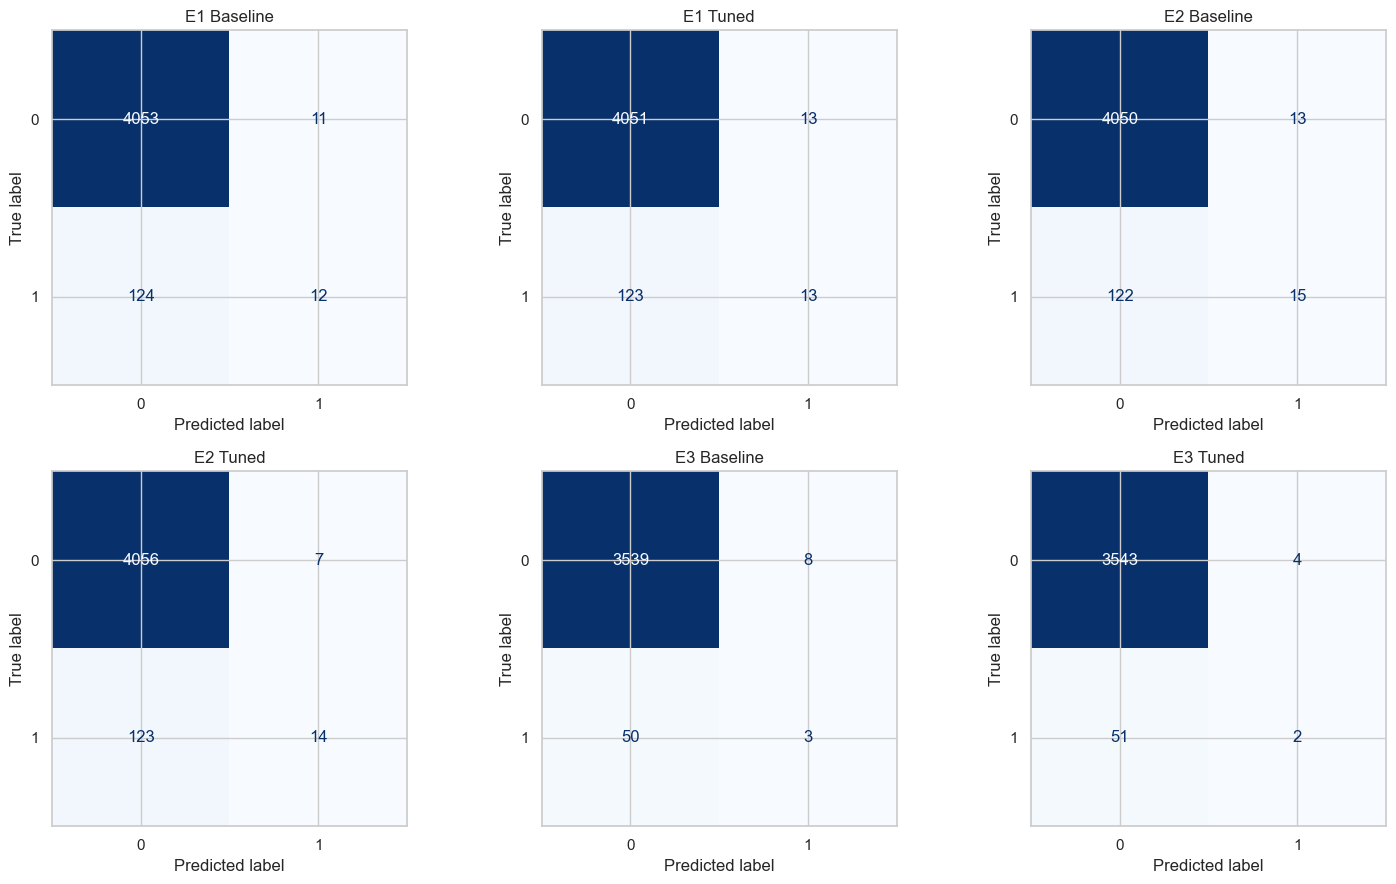

In [41]:
# ==========================================================
# 8.3 Confusion Matrix Analysis
# ==========================================================

from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

models = [
    ("E1 Baseline", baseline_xgb, X_test_final, y_test),
    ("E1 Tuned", tuned_xgb, X_test_final, y_test),
    ("E2 Baseline", baseline_xgb_sem, X_test_sem_final, y_test_sem),
    ("E2 Tuned", tuned_xgb_sem, X_test_sem_final, y_test_sem),
    ("E3 Baseline", baseline_xgb_temp, X_test_temp_final, y_test_temp),
    ("E3 Tuned", tuned_xgb_temp, X_test_temp_final, y_test_temp),
]

for ax, (title, model, X_eval, y_eval) in zip(axes.flatten(), models):

    ConfusionMatrixDisplay.from_estimator(
        model,
        X_eval,
        y_eval,
        cmap="Blues",
        ax=ax,
        colorbar=False
    )

    ax.set_title(title)

plt.tight_layout()

plt.show()

### 8.4 ROC Curve Analysis


Receiver Operating Characteristic (ROC) curves evaluate the ranking capability of the trained XGBoost models by analysing the trade-off between the True Positive Rate and False Positive Rate across different classification thresholds.

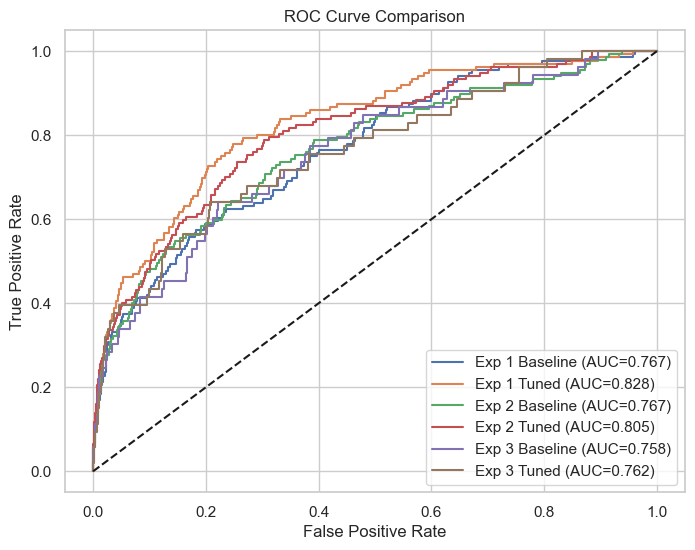

In [42]:
# ==========================================================
# 8.4 ROC Curve Analysis
# ==========================================================

from sklearn.metrics import roc_curve, roc_auc_score

plt.figure(figsize=(8,6))

roc_models = [
    ("Exp 1 Baseline", y_test, baseline_xgb_probabilities),
    ("Exp 1 Tuned", y_test, tuned_xgb_probabilities),
    ("Exp 2 Baseline", y_test_sem, baseline_xgb_sem_probabilities),
    ("Exp 2 Tuned", y_test_sem, tuned_xgb_sem_probabilities),
    ("Exp 3 Baseline", y_test_temp, baseline_xgb_temp_probabilities),
    ("Exp 3 Tuned", y_test_temp, tuned_xgb_temp_probabilities),
]

for name, target, probabilities in roc_models:

    fpr, tpr, _ = roc_curve(
        target,
        probabilities
    )

    auc = roc_auc_score(
        target,
        probabilities
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC={auc:.3f})"
    )

plt.plot([0,1],[0,1],"k--")

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()

plt.grid(True)

plt.show()

### 8.5 Precision–Recall Analysis


Precision–Recall curves provide additional insight into classifier behaviour under class imbalance by evaluating the trade-off between Precision and Recall across varying decision thresholds.

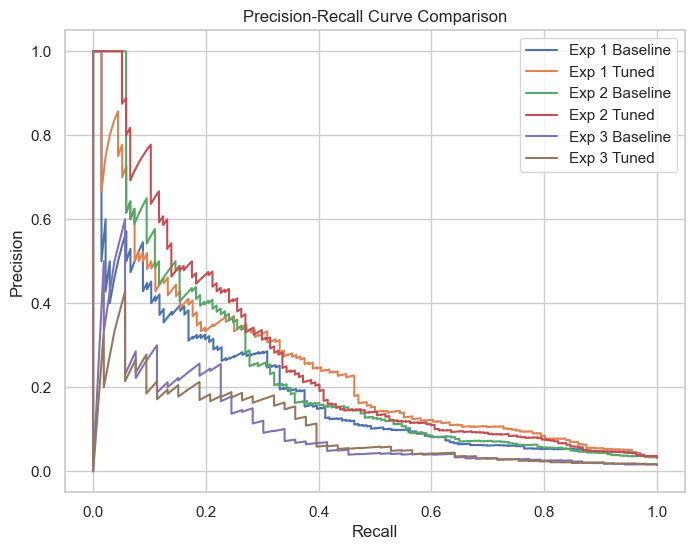

In [43]:
# ==========================================================
# 8.5 Precision-Recall Curve Analysis
# ==========================================================

from sklearn.metrics import precision_recall_curve

plt.figure(figsize=(8,6))

pr_models = [
    ("Exp 1 Baseline", y_test, baseline_xgb_probabilities),
    ("Exp 1 Tuned", y_test, tuned_xgb_probabilities),
    ("Exp 2 Baseline", y_test_sem, baseline_xgb_sem_probabilities),
    ("Exp 2 Tuned", y_test_sem, tuned_xgb_sem_probabilities),
    ("Exp 3 Baseline", y_test_temp, baseline_xgb_temp_probabilities),
    ("Exp 3 Tuned", y_test_temp, tuned_xgb_temp_probabilities),
]

for name, target, probabilities in pr_models:

    precision, recall, _ = precision_recall_curve(
        target,
        probabilities
    )

    plt.plot(
        recall,
        precision,
        label=name
    )

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.title("Precision-Recall Curve Comparison")

plt.legend()

plt.grid(True)

plt.show()

### 8.6 Model Ranking


In [44]:
# ==========================================================
# 8.6 Model Ranking
# ==========================================================

ranking = (
    experiment_results
    .sort_values(
        by="F1-Score",
        ascending=False
    )
    .reset_index(drop=True)
)

display(ranking)

,Experiment,Configuration,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
0,Experiment 2,Baseline,0.9679,0.5357,0.1095,0.1818,0.7672,0.2331
1,Experiment 2,Tuned,0.9690,0.6667,0.1022,0.1772,0.8049,0.2640
2,Experiment 1,Tuned,0.9676,0.5000,0.0956,0.1605,0.8276,0.2449
3,Experiment 1,Baseline,0.9679,0.5217,0.0882,0.1509,0.7671,0.1893
4,Experiment 3,Baseline,0.9839,0.2727,0.0566,0.0938,0.7576,0.1121
5,Experiment 3,Tuned,0.9847,0.3333,0.0377,0.0678,0.7622,0.1062


### 8.7 Evaluation Summary



The XGBoost classifier demonstrated the strongest overall predictive performance among the evaluated ensemble configurations. Across the three experimental strategies, the semester-aware stratified split again produced the most balanced results, indicating that preserving academic semester distributions improves model learning and generalisation.

Hyperparameter optimisation increased classification accuracy, precision, and Precision–Recall AUC; however, a slight reduction in recall resulted in the baseline semester-aware model achieving the highest overall F1-Score. This suggests that the tuned configuration favoured more conservative positive predictions, improving precision at the expense of sensitivity.

As observed in the previous models, the temporal split remained the most challenging evaluation scenario. The reduction in recall and F1-Score under this experimental setting indicates that distributional differences between historical and future student cohorts continue to affect predictive performance despite the increased modelling capability of gradient boosting.

### 8.8 Findings

- All six XGBoost configurations were successfully evaluated under a common experimental framework.
- The semester-aware stratified split produced the strongest overall predictive performance, with the baseline configuration achieving the highest F1-Score.
- Hyperparameter optimisation improved precision, overall accuracy, and probability ranking performance, although these gains were accompanied by a small reduction in recall.
- Performance declined under the temporal split, confirming that future cohort prediction remains the most challenging deployment scenario.
- The best-performing XGBoost model will be carried forward to the explainability and fairness assessment stages.

## 9. Explainability

### 9.1 Explainability Objective



XGBoost provides intrinsic feature importance measures through the contribution of individual features to the gradient-boosted decision trees. This section analyses feature importance using the model's built-in gain-based importance estimates and complements these findings with SHAP (SHapley Additive exPlanations) to improve transparency and interpretability.

Together, these techniques provide both global and local explanations of the XGBoost decision-making process while supporting comparison with the explainability analyses performed for the remaining machine learning models.

### 9.2 Feature Importance

In [45]:
# ==========================================================
# 9.2 Feature Importance
# ==========================================================

feature_names = (
    numerical_features +
    list(
        encoder.get_feature_names_out(
            categorical_features
        )
    )
)

importance_df = pd.DataFrame({

    "Feature": feature_names,

    "Importance": baseline_xgb_sem.feature_importances_

})

importance_df = (

    importance_df

    .sort_values(

        "Importance",

        ascending=False

    )

)

display(importance_df.head(20))

,Feature,Importance
22,spra,0.1141
23,sei,0.0800
34,semester_phase_Late,0.0414
30,savings_behavior_Consistent Saver,0.0363
28,major_category_Humanities,0.0344
11,gig_income_flag,0.0316
4,monthly_inflow_mean,0.0306
5,aid_disbursement_flag,0.0303
26,major_category_Arts,0.0289
20,opr,0.0280


### 9.3 Feature Importance Visualisation


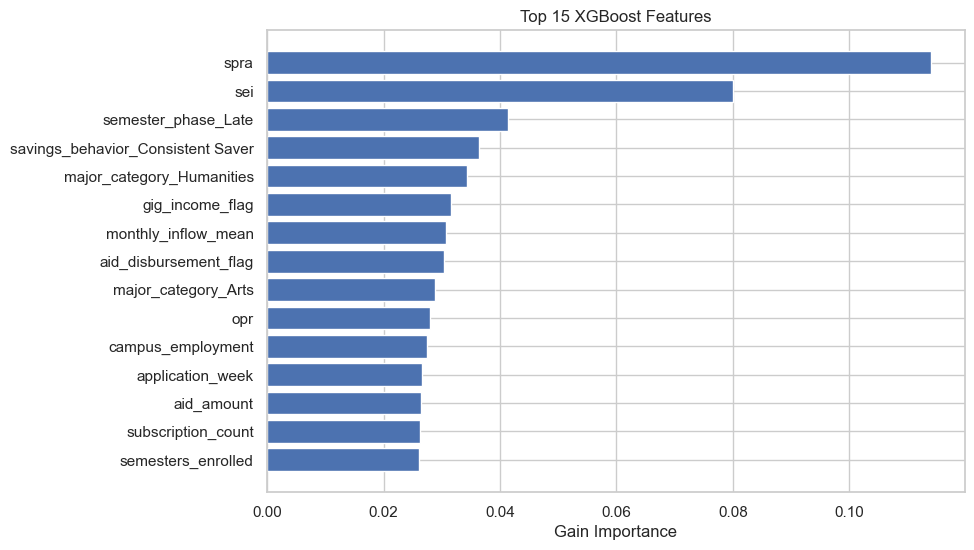

In [46]:
# ==========================================================
# 9.3 Feature Importance Visualization
# ==========================================================

plt.figure(figsize=(9,6))

top_features = (

    importance_df

    .head(15)

    .sort_values("Importance")

)

plt.barh(

    top_features["Feature"],

    top_features["Importance"]

)

plt.xlabel("Gain Importance")

plt.title("Top 15 XGBoost Features")

plt.grid(True)

plt.show()

### 9.4 SHAP Analysis

In [47]:
# ==========================================================
# 9.4 SHAP Analysis
# ==========================================================

import shap

best_xgb_model = baseline_xgb_sem
best_xgb_test = X_test_sem_final

explainer = shap.TreeExplainer(
    best_xgb_model
)

sample = best_xgb_test[:100]

shap_values = explainer.shap_values(sample)

print("SHAP values computed successfully.")

SHAP values computed successfully.


### 9.5 SHAP Summary Plot

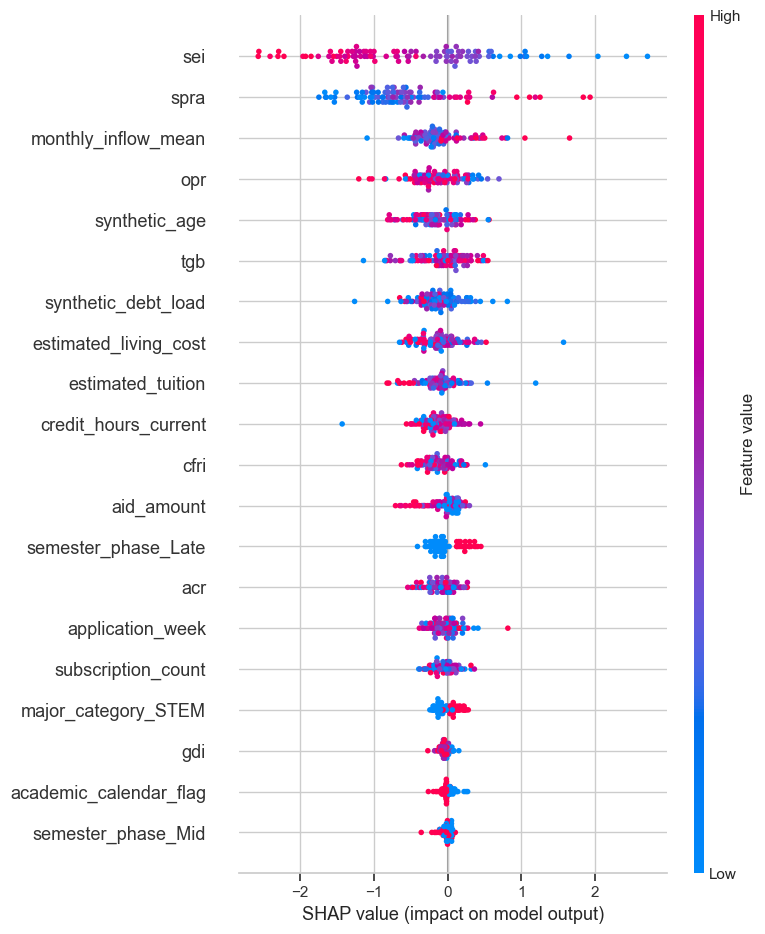

In [48]:
# ==========================================================
# 9.5 SHAP Summary Plot
# ==========================================================


plt.figure(figsize=(12,8))

if isinstance(shap_values, list):

    shap.summary_plot(

        shap_values[1],

        sample,

        feature_names=feature_names

    )

elif len(np.array(shap_values).shape) == 3:

    shap.summary_plot(

        shap_values[:, :, 1],

        sample,

        feature_names=feature_names

    )

else:

    shap.summary_plot(

        shap_values,

        sample,

        feature_names=feature_names

    )

### 9.6 Explainability Summary



XGBoost provides intrinsic gain-based feature importance estimates through the contribution of individual predictors to the gradient-boosting process. These importance estimates were complemented by SHAP analysis to provide a comprehensive understanding of the model's prediction behaviour.

Together, gain-based importance and SHAP improve model interpretability by identifying the most influential variables while providing transparent explanations of the selected XGBoost classifier.

### 9.7 Findings



- Gain-based feature importance identified the variables contributing most strongly to XGBoost predictions.
- SHAP analysis provided additional global explanations of feature influence and improved transparency of the selected boosting model.
- The explainability techniques demonstrated that the selected XGBoost model maintains strong predictive capability while remaining interpretable through post-hoc explanation methods.
- The identified feature importance patterns will be compared with Logistic Regression, Support Vector Machine, and Random Forest during the final benchmarking stage.

## 10. Fairness Assessment

### 10.1 Fairness Objective



This section evaluates the fairness of the selected XGBoost classifier by comparing predictive performance across selected demographic and educational groups. The objective is to determine whether the model demonstrates consistent predictive behaviour while maintaining strong overall classification performance.

The fairness assessment complements the predictive evaluation and explainability analyses by examining model consistency beyond conventional accuracy-based metrics.

### 10.2 Protected Feature Analysis

In [49]:
# ==========================================================
# 10.2 Protected Feature Analysis
# ==========================================================

protected_features = [
    "synthetic_age",
    "academic_year",
    "campus_employment"
]

protected_summary = processed_df[
    protected_features
].describe(include="all").T

display(protected_summary)

,count,mean,std,min,25%,50%,75%,max
synthetic_age,21000.0000,21.5256,1.7602,18.0000,20.2972,21.5093,22.7265,29.5624
academic_year,21000.0000,2.4066,1.0111,1.0000,2.0000,2.0000,3.0000,4.0000
campus_employment,21000.0000,0.2510,0.4336,0.0000,0.0000,0.0000,1.0000,1.0000


### 10.3 Group-wise Performance

In [50]:
# ==========================================================
# 10.3 Group-wise Performance
# ==========================================================

from sklearn.metrics import accuracy_score, f1_score

fairness_results = []

evaluation_df = X_test_sem.copy()

evaluation_df["Actual"] = y_test_sem.values

evaluation_df["Prediction"] = baseline_xgb_sem_predictions

for feature in protected_features:

    for group in sorted(evaluation_df[feature].dropna().unique()):

        subset = evaluation_df[
            evaluation_df[feature] == group
        ]

        fairness_results.append({

            "Feature": feature,

            "Group": group,

            "Samples": len(subset),

            "Accuracy":
                accuracy_score(
                    subset["Actual"],
                    subset["Prediction"]
                ),

            "F1-Score":
                f1_score(
                    subset["Actual"],
                    subset["Prediction"],
                    zero_division=0
                )

        })

fairness_df = pd.DataFrame(fairness_results)

display(fairness_df)

,Feature,Group,Samples,Accuracy,F1-Score
0,synthetic_age,18.0000,105,0.9524,0.0000
1,synthetic_age,18.0102,1,1.0000,0.0000
2,synthetic_age,18.0162,1,0.0000,0.0000
3,synthetic_age,18.0211,1,1.0000,0.0000
4,synthetic_age,18.0258,1,1.0000,0.0000
...,...,...,...,...,...
4097,academic_year,2.0000,1372,0.9643,0.1967
4098,academic_year,3.0000,1188,0.9773,0.1818
4099,academic_year,4.0000,721,0.9834,0.1429
4100,campus_employment,0.0000,3122,0.9680,0.1667


### 10.4 Fairness Metrics

In [51]:
# ==========================================================
# 10.4 Fairness Metrics
# ==========================================================

fairness_summary = (

    fairness_df

    .groupby("Feature")[["Accuracy", "F1-Score"]]

    .agg(["min", "max", "mean"])

    .round(4)

)

display(fairness_summary)

Accuracy               F1-Score              
                       min    max   mean      min    max   mean
Feature                                                        
academic_year       0.9489 0.9834 0.9684   0.1429 0.1967 0.1742
campus_employment   0.9675 0.9680 0.9678   0.1667 0.2222 0.1944
synthetic_age       0.0000 1.0000 0.9683   0.0000 1.0000 0.0037

### 10.5 Fairness Summary



Fairness assessment was conducted using the best-performing XGBoost configuration identified during the experimental evaluation. Predictive performance was examined across the selected demographic and educational attributes to determine whether the classifier exhibited consistent behaviour across different student groups.

Group-wise Accuracy and F1-Score were compared to identify potential disparities while maintaining the same evaluation methodology adopted throughout this research. The assessment complements the predictive evaluation by examining model consistency in addition to overall classification performance.

### 10.6 Findings



- Fairness evaluation was performed using the best-performing XGBoost model obtained from the semester-aware stratified experiment.
- Group-wise Accuracy and F1-Score were compared across the selected demographic and educational attributes to assess prediction consistency.
- No fairness optimisation techniques were applied, allowing the evaluation to reflect the natural behaviour of the trained XGBoost classifier.
- The fairness assessment complements the predictive and explainability analyses and will be compared with the remaining machine learning models during the final benchmarking stage.

## 11.Nemotron

## 12. Conclusions

### 12.1 Research Summary



This notebook presented the complete development and evaluation of an Extreme Gradient Boosting (XGBoost) classifier for the Student Credit Risk Assessment framework. The study followed a structured machine learning workflow consisting of feature validation, preprocessing, multiple experimental data partitioning strategies, hyperparameter optimisation, comprehensive model evaluation, explainability analysis, and fairness assessment.

Three complementary experimental configurations were investigated to evaluate the behaviour of XGBoost under different deployment scenarios. The conventional stratified split established a baseline benchmark, the semester-aware stratified split preserved academic progression while maintaining balanced class distributions, and the temporal split evaluated the model's ability to generalise to future student cohorts. Together, these experiments provided a comprehensive assessment of predictive capability, robustness, and real-world deployment performance.

Beyond predictive evaluation, explainability was incorporated through gain-based feature importance and SHAP analysis to improve model transparency, while fairness assessment examined predictive consistency across selected demographic and educational groups. This integrated evaluation provides a comprehensive understanding of the strengths and limitations of XGBoost beyond conventional classification metrics.

### 12.2 Key Findings




The XGBoost classifier demonstrated the strongest overall predictive capability among the evaluated machine learning models developed throughout this research. Across the three experimental configurations, the semester-aware stratified split consistently produced the most balanced predictive performance, indicating that preserving academic semester distributions improves model learning and generalisation.

Although hyperparameter optimisation improved precision, overall accuracy, and probability ranking performance, the baseline semester-aware configuration achieved the highest F1-Score because of its stronger balance between precision and recall. This highlights the importance of evaluating multiple performance metrics rather than relying solely on optimisation results when selecting the final predictive model.

Explainability analysis demonstrated that XGBoost provides meaningful estimates of feature importance through gain-based importance measures and SHAP analysis, while the fairness assessment complemented these findings by evaluating predictive consistency across the selected demographic and educational groups.

### 12.3 Limitations



Several limitations should be considered when interpreting the findings presented in this notebook.

The experiments were conducted using a synthetically generated student credit dataset designed to approximate realistic educational lending scenarios. Although the synthetic data generation framework incorporates domain knowledge and extensive validation procedures, it cannot fully reproduce the behavioural complexity and financial variability observed in real-world student loan portfolios.

While XGBoost effectively captures complex non-linear relationships and feature interactions, its ensemble structure is inherently less interpretable than linear machine learning models. Consequently, post-hoc explainability techniques such as gain-based feature importance and SHAP are required to improve transparency and support interpretation of model predictions.

The reduction in predictive performance observed under the temporal split highlights the continued challenge of distributional shifts between historical and future student cohorts. Furthermore, the current implementation evaluates static student profiles rather than modelling longitudinal financial behaviour. Future longitudinal educational lending datasets would enable more robust temporal modelling and potentially improve prediction stability under real-world deployment conditions.

### 12.4 Future Work



Future work will consolidate the findings from Logistic Regression, Support Vector Machine, Random Forest, and XGBoost into a comprehensive comparative evaluation using the common preprocessing pipeline, experimental design, evaluation metrics, explainability framework, and fairness assessment methodology established throughout this research. Maintaining a consistent evaluation framework enables objective comparison of predictive capability, robustness, interpretability, and fairness across all machine learning models.

Following completion of the machine learning evaluation, an integrated comparison with the Nemotron reasoning framework will be conducted to investigate differences in predictive behaviour, transparency, robustness, and practical applicability. This consolidated benchmarking study will support the identification of the most appropriate modelling approach for student credit risk assessment under varying deployment scenarios.

Future research may also investigate more advanced boosting techniques, temporal deep learning architectures, and richer longitudinal educational lending datasets capable of modelling evolving financial behaviour and improving early identification of students at elevated credit risk.